# Hypergraph Stochastic Block Model - Simulations Part A

- Uniform: this notebook
- Non-Uniform: see nu_analysis.ipynb

In [1]:
import sys
from dataclasses import dataclass
from pathlib import Path

candidates = [Path.cwd(), Path.cwd() / "code", *Path.cwd().parents]
CODE_ROOT = next(p for p in candidates if (p / "src" / "__init__.py").is_file())
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from src.hg_class import HypergraphDataset
from src.hsbm import generate_nonuniform_hsbm, generate_uniform_hsbm

In [2]:
from src.hellinger_dist import hellinger_distance
from IPython.display import display
import matplotlib
import matplotlib.pyplot as plt
import xgi

import numpy as np
import pandas as pd
import seaborn as sns
from plotnine import *

sns.set_theme(style="whitegrid", context="talk")
Zissou1 = ["#3B9AB2", "#78B7C5", "#EBCC2A", "#E1AF00", "#F21A00"]
Zissou1Continuous = ["#3A9AB2", "#6FB2C1", "#91BAB6", "#A5C2A3", "#BDC881", "#DCCB4E", "#E3B710", "#E79805", "#EC7A05", "#EF5703", "#F11B00"]


## Helpers

In [3]:
# Correlation Heatmap

DERIVED_DIR = CODE_ROOT / "simulations" / "u_derived"
FIGURE_DIR = CODE_ROOT / "simulations" / "u_figures"
INCLUDE_BE = False

def plot_correlation(cihi, hfrc, horc, config_name, be=None):
    """Return a Pearson-correlation heatmap for the curvature metrics."""
    horc_columns = [
        column
        for column in horc.columns
        if column == "horc" or column.endswith("_a0p0")
    ]
    labels = {
        "cihi": "CIHI",
        "hfrc": "HFRC",
        "be": "BE",
        "horc": "UW Clique (Mean)",
        "horc_uw_clique_max_a0p0": "UW Clique (Max)",
        "horc_w_clique_mean_a0p0": "W Clique (Mean)",
        "horc_w_clique_max_a0p0": "W Clique (Max)",
        "horc_uw_star_mean_a0p0": "UW Star (Mean)",
        "horc_uw_star_max_a0p0": "UW Star (Max)",
    }

    metric_data = {"cihi": as_float_array(cihi), "hfrc": as_float_array(hfrc)}
    if be is not None:
        metric_data["be"] = as_float_array(be)

    data = pd.concat(
        [
            pd.DataFrame(metric_data),
            horc[horc_columns],
        ],
        axis=1,
    )
    corr = data.corr(method="pearson").rename(index=labels, columns=labels)
    corr_long = pd.DataFrame(
        [
            (row, column, corr.loc[row, column])
            for row in corr.index
            for column in corr.columns
        ],
        columns=["metric_y", "metric_x", "correlation"],
    )
    corr_long["label"] = corr_long["correlation"].map(lambda value: f"{value:.2f}")
    corr_long["text_color"] = np.where(
        corr_long["correlation"].abs() > 0.75, "white", "black"
    )
    order = list(corr.columns)
    corr_long["metric_x"] = pd.Categorical(corr_long["metric_x"], order, ordered=True)
    corr_long["metric_y"] = pd.Categorical(corr_long["metric_y"], order[::-1], ordered=True)

    return (
        ggplot(corr_long, aes("metric_x", "metric_y", fill="correlation"))
        + geom_tile()
        + geom_text(aes(label="label", color="text_color"), size=8)
        + scale_fill_gradientn(
            colors=Zissou1Continuous,
            limits=(-1, 1),
            name="Pearson\ncorrelation",
        )
        + scale_color_identity()
        + coord_equal()
        + labs(title=f"Uniform - {config_name}", x="", y="")
        + theme_minimal()
        + theme(
            figure_size=(6, 5),
            plot_title=element_text(size=14, ha="center"),
            axis_text_x=element_text(rotation=45, ha="right", size=9),
            axis_text_y=element_text(size=9),
            panel_grid=element_blank(),
        )
    )

# Hellinger Distance
def hellinger_by_group(frame, value_col, label_col="edge_label"):
    values = [
        frame.loc[frame[label_col] == label, value_col].dropna().to_numpy()
        for label in ("intra", "inter")
    ]
    return hellinger_distance(*values)
    
def as_float_array(values):
    return np.array([np.nan if x is None else x for x in values], dtype=float)


# Hypergraph Visualization
def vis_hg(data, save_path=None):
    H = xgi.Hypergraph(data.hyperedges)
    # node position
    pos = xgi.barycenter_spring_layout(H, seed=123, iterations=500)
    # edge color
    cmap = matplotlib.colormaps.get_cmap('RdYlBu_r')
    edge_color = {key: cmap((cihi+1)/2) for key, cihi in enumerate(data.get_cihi())}
    fig, ax = plt.subplots(figsize=(4, 3))
    xgi.draw(H, pos=pos, node_size=3, node_lw = 0, node_ec = "black", node_fc = 'black',
            edge_fc = edge_color, edge_ec = edge_color, dyad_color = edge_color, dyad_lw = 1,
            alpha=0.7, hull = True, radius = 0.02, rescale_sizes=False);
    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    return fig


# Uniform HSBM analysis helpers
def uniform_config_signature(config):
    return (
        config.k_uniform,
        config.block_sizes,
        config.community_edge_probs,
        config.seed,
    )


def load_uniform_dataset(config):
    DERIVED_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = DERIVED_DIR / f"{config.name}.pkl"
    config_signature = uniform_config_signature(config)

    ds = HypergraphDataset.load(cache_path) if cache_path.exists() else None
    has_integer_nodes = (
        ds is not None
        and all(isinstance(node, int) for edge in ds.hyperedges[:1] for node in edge)
    )
    if (
        ds is None
        or getattr(ds, "generation_config", None) != config_signature
        or getattr(ds, "edge_labels", None) is None
        or not has_integer_nodes
    ):
        hyperedges, node_labels, community_counts = generate_uniform_hsbm(
            k_uniform=config.k_uniform,
            block_sizes=config.block_sizes,
            community_edge_probs=config.community_edge_probs,
            seed=config.seed,
        )
        edge_labels = ["intra" if count == 1 else "inter" for count in community_counts]
        ds = HypergraphDataset(
            hyperedges=hyperedges,
            node_labels=node_labels,
            edge_labels=edge_labels,
        )
        ds.community_counts = community_counts
        ds.generation_config = config_signature
        ds.save(cache_path)

    return ds, cache_path


def compute_curvature_values(data, include_be=False):
    cihi = data.get_cihi()
    hfrc = data.get_hfrc()
    horc = pd.DataFrame(data.get_horc(all_configurations=True), dtype=float)
    be = data.get_be() if include_be else None
    return cihi, hfrc, horc, be


def plot_curvature_boxplot(cihi, hfrc, horc, edge_labels, be=None):
    horc = horc.copy()
    horc["edge_label"] = edge_labels
    horc_metrics = [c for c in horc.columns if c == "horc" or c.startswith("horc_")]
    horc_scores = {col: hellinger_by_group(horc, col) for col in horc_metrics}
    best_horc = max(
        horc_scores,
        key=lambda col: -np.inf if np.isnan(horc_scores[col]) else horc_scores[col],
    )

    plot_data = {
        "edge_label": edge_labels,
        "cihi": as_float_array(cihi),
        "hfrc": as_float_array(hfrc),
    }
    metric_names = {"cihi": "CIHI", "hfrc": "HFRC"}
    if be is not None:
        plot_data["be"] = as_float_array(be)
        metric_names["be"] = "BE"
    plot_data["horc"] = horc[best_horc]
    metric_names["horc"] = "HORC*"

    plot_df = pd.DataFrame(plot_data)

    h_values = {
        metric: hellinger_by_group(plot_df, metric)
        for metric in metric_names
    }
    metric_titles = {
        metric: f"{name}\n(H = {h_values[metric]:.3f})"
        for metric, name in metric_names.items()
    }

    long_df = plot_df.melt(id_vars="edge_label", var_name="metric", value_name="score")
    long_df["edge_label"] = pd.Categorical(
        long_df["edge_label"], ["intra", "inter"], ordered=True
    )
    long_df["metric_title"] = pd.Categorical(
        long_df["metric"].map(metric_titles),
        list(metric_titles.values()),
        ordered=True,
    )

    p = (
        ggplot(long_df, aes("edge_label", "score", fill="edge_label"))
        + geom_boxplot(width=0.8)
        + facet_wrap("metric_title", scales="free_y", nrow=1)
        + scale_fill_manual(values={"intra": Zissou1[1], "inter": Zissou1[2]})
        + labs(x="", y="")
        + theme_minimal()
        + theme(
            figure_size=(2.7 * len(metric_names), 2),
            legend_position="none",
            panel_spacing_x=0.05,
            strip_text=element_text(size=11),
            axis_title_y=element_text(size=11),
            axis_text=element_text(size=10),
        )
    )
    return p, best_horc, h_values


def analyze_uniform_config(
    config,
    save_figures=True,
    show_hypergraph=True,
    include_be=False,
):
    data, cache_path = load_uniform_dataset(config)
    cihi, hfrc, horc, be = compute_curvature_values(
        data,
        include_be=include_be,
    )
    p_corr = plot_correlation(cihi, hfrc, horc, config.name, be=be)
    p, best_horc, h_values = plot_curvature_boxplot(
        cihi, hfrc, horc, data.edge_labels, be=be
    )

    figure_paths = {
        "p_corr": FIGURE_DIR / f"{config.name}_corr.pdf",
        "p": FIGURE_DIR / f"{config.name}_box.pdf",
        "vis_hg": FIGURE_DIR / f"{config.name}_hg.pdf",
    }
    if save_figures:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        p_corr.save(figure_paths["p_corr"], verbose=False)
        p.save(figure_paths["p"], verbose=False)

    hg_fig = None
    if show_hypergraph:
        hg_fig = vis_hg(
            data,
            save_path=figure_paths["vis_hg"] if save_figures else None,
        )

    return {
        "config": config,
        "ds": data,
        "cihi": cihi,
        "hfrc": hfrc,
        "be": be,
        "horc": horc,
        "best_horc": best_horc,
        "h_values": h_values,
        "p_corr": p_corr,
        "p": p,
        "vis_hg": hg_fig,
        "cache_path": cache_path,
        "figure_paths": figure_paths,
    }

## Uniform

In [4]:
@dataclass(frozen=True)
class UniformConfig:
    """Configuration for one uniform HSBM sample."""

    name: str
    k_uniform: int
    block_sizes: tuple[int, ...]
    community_edge_probs: tuple[float, ...]
    seed: int = 123

UNIFORM_CONFIGS = (
    UniformConfig("k3_com2", 3, (15, 15), (0.1, 0.001)),
    UniformConfig("k3_com2_unbal", 3, (15, 25), (0.1, 0.001)),
    UniformConfig("k3_com3", 3, (15, 15, 15), (0.1, 0.001, 0.001)),
    UniformConfig("k3_com3_unbal",3,(40, 30, 20),(0.1, 0.001, 0.001),),
    UniformConfig("k4_com2", 4, (15, 15), (0.1, 0.001)),
    UniformConfig("k4_com2_unbal", 4, (20, 40), (1e-2, 1e-4)),
    UniformConfig("k4_com3",4,(15, 15, 15),(0.1, 0.001, 0.001),),
    UniformConfig("k4_com3_unbal",4,(40, 30, 20),(1e-2, 1e-4, 1e-4),),
)

In [5]:
"""Toy Example - Figure 1a in the paper"""
config = UNIFORM_CONFIGS[0]
ds, cache_path = load_uniform_dataset(config)
cache_path

PosixPath('/Users/shiyi/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Research/CIHI/Lower Ricci Curvature for Hypergraph/code/simulations/u_derived/k3_com2.pkl')

In [6]:
cihi, hfrc, horc, be = compute_curvature_values(ds, include_be=INCLUDE_BE)

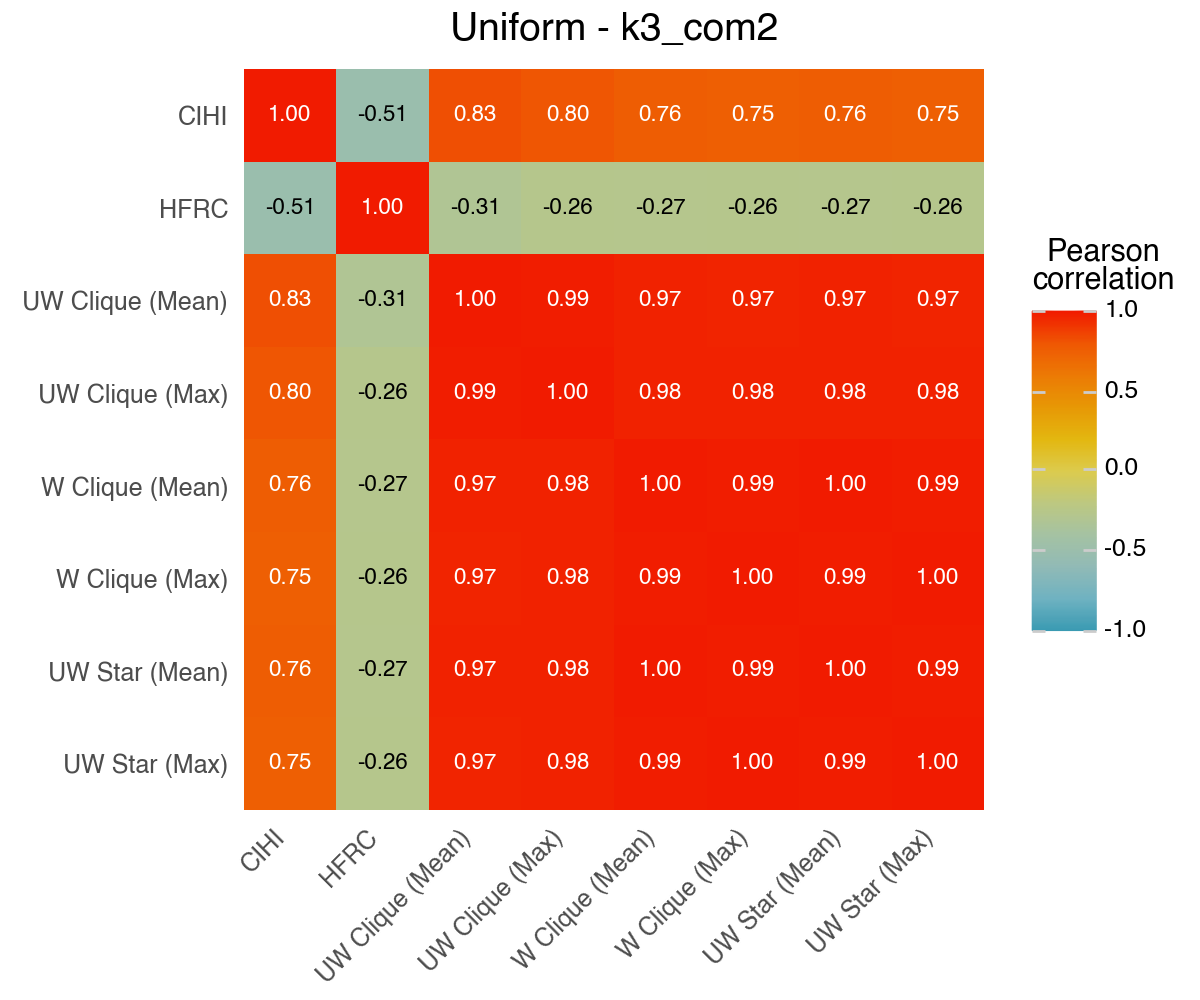

In [7]:
p_corr = plot_correlation(cihi, hfrc, horc, config.name, be=be)
p_corr.save(FIGURE_DIR / f"{config.name}_corr.pdf", verbose=False)
p_corr

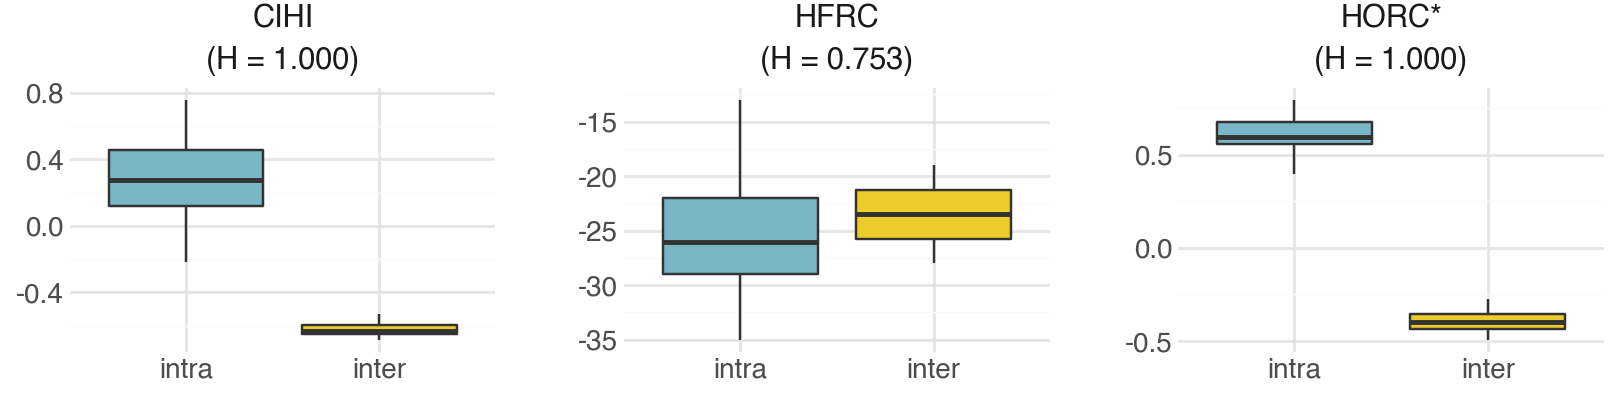

In [8]:
p, best_horc, h_values = plot_curvature_boxplot(
    cihi, hfrc, horc, ds.edge_labels, be=be
)
p.save(FIGURE_DIR / f"{config.name}_box.pdf", verbose=False)
p

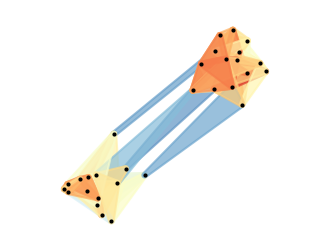

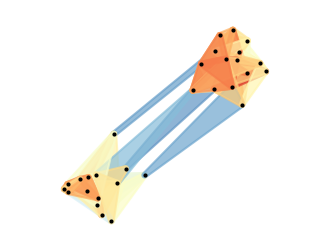

In [ ]:
hg_fig = vis_hg(ds, save_path=FIGURE_DIR / f"{config.name}_hg.pdf")
toy_result = {
    "config": config,
    "ds": ds,
    "cihi": cihi,
    "hfrc": hfrc,
    "be": be,
    "horc": horc,
    "best_horc": best_horc,
    "h_values": h_values,
    "p_corr": p_corr,
    "p": p,
    "vis_hg": hg_fig,
    "cache_path": cache_path,
    "figure_paths": {
        "p_corr": FIGURE_DIR / f"{config.name}_corr.pdf",
        "p": FIGURE_DIR / f"{config.name}_box.pdf",
        "vis_hg": FIGURE_DIR / f"{config.name}_hg.pdf",
    },
}


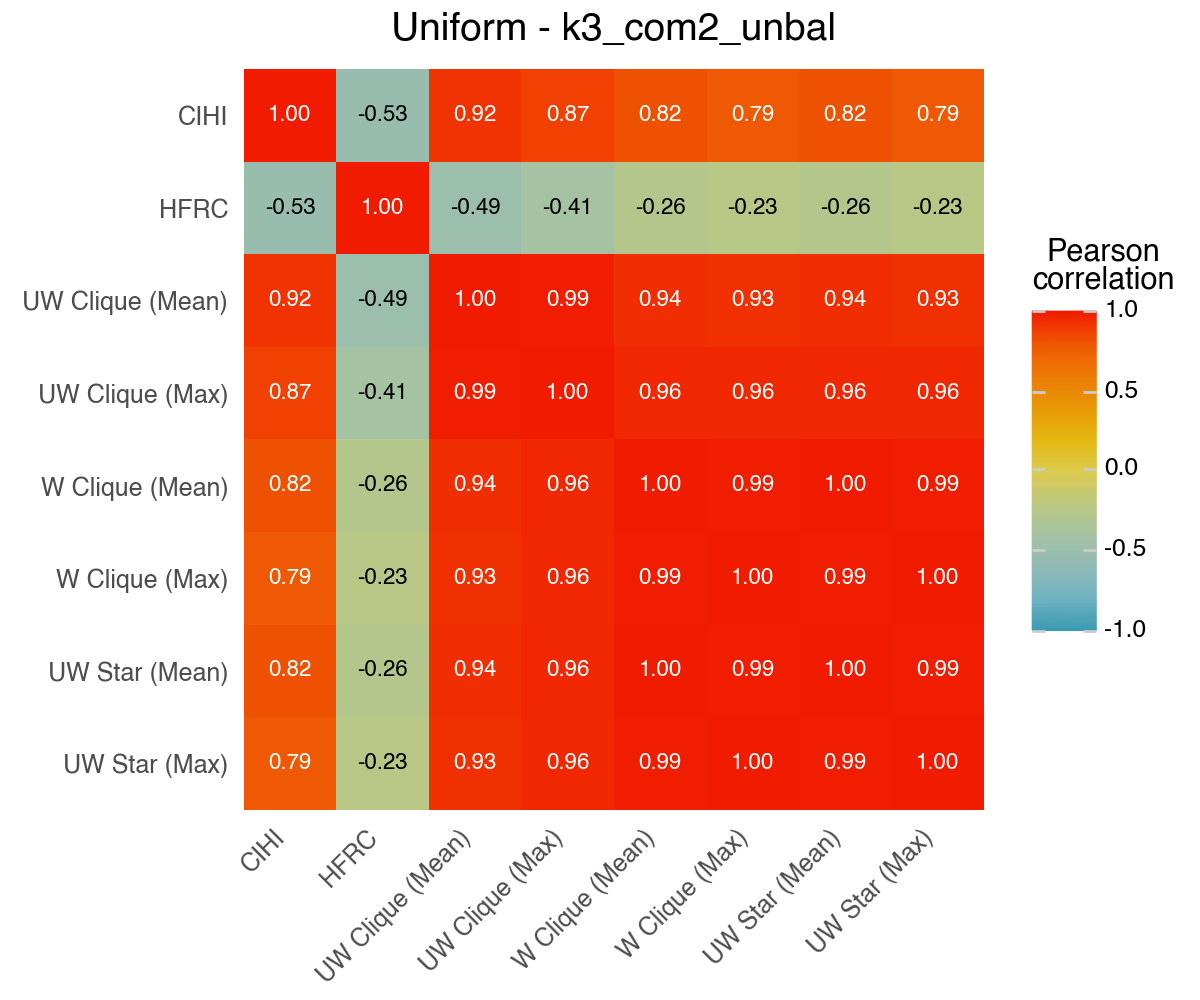

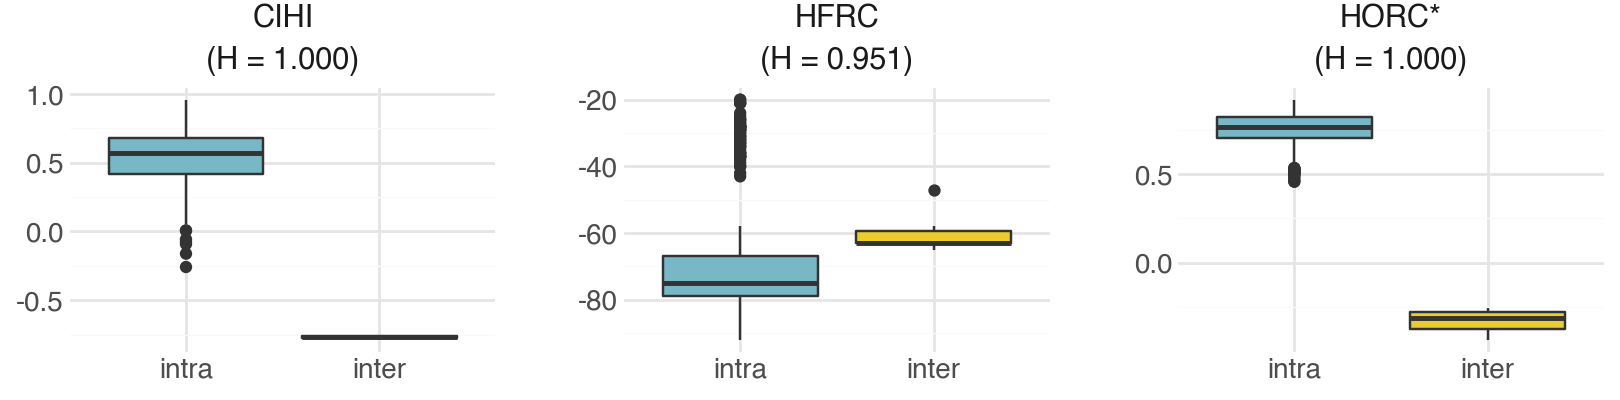

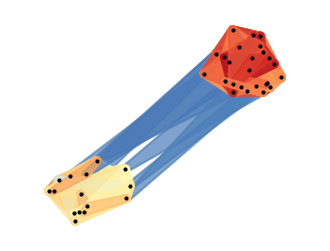

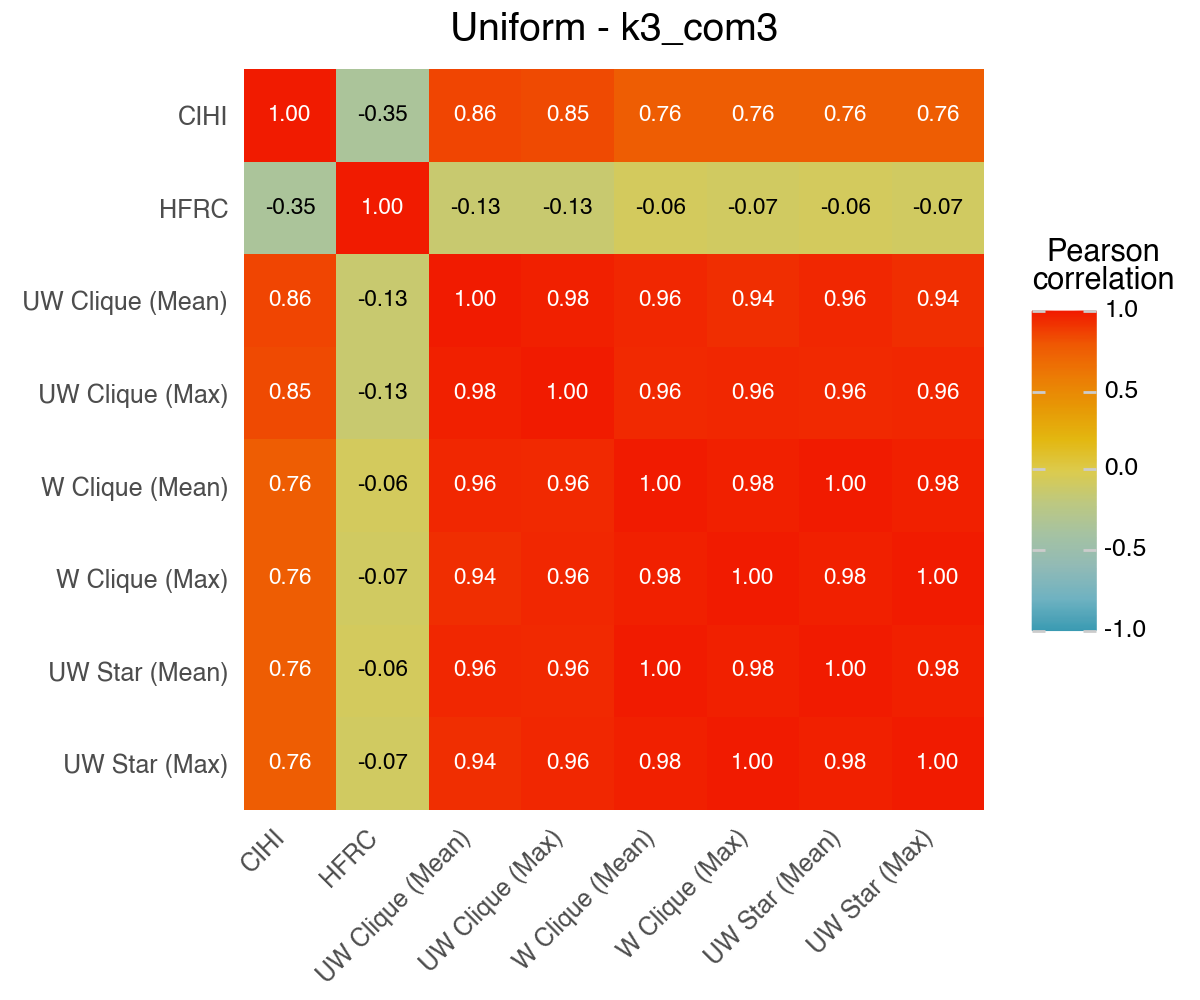

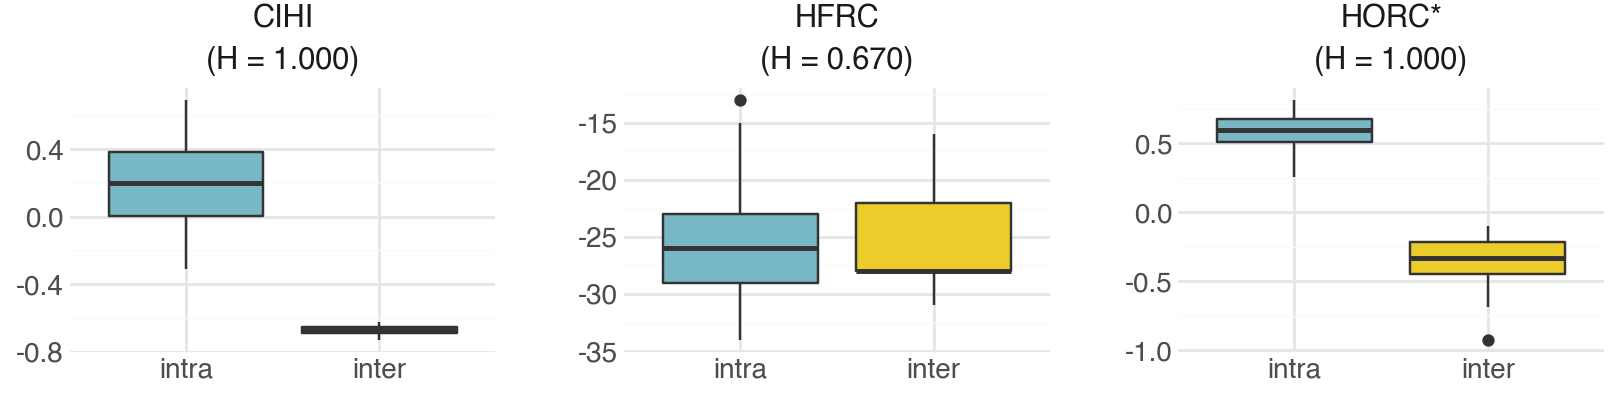

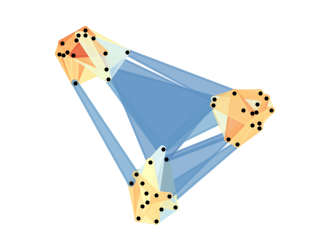

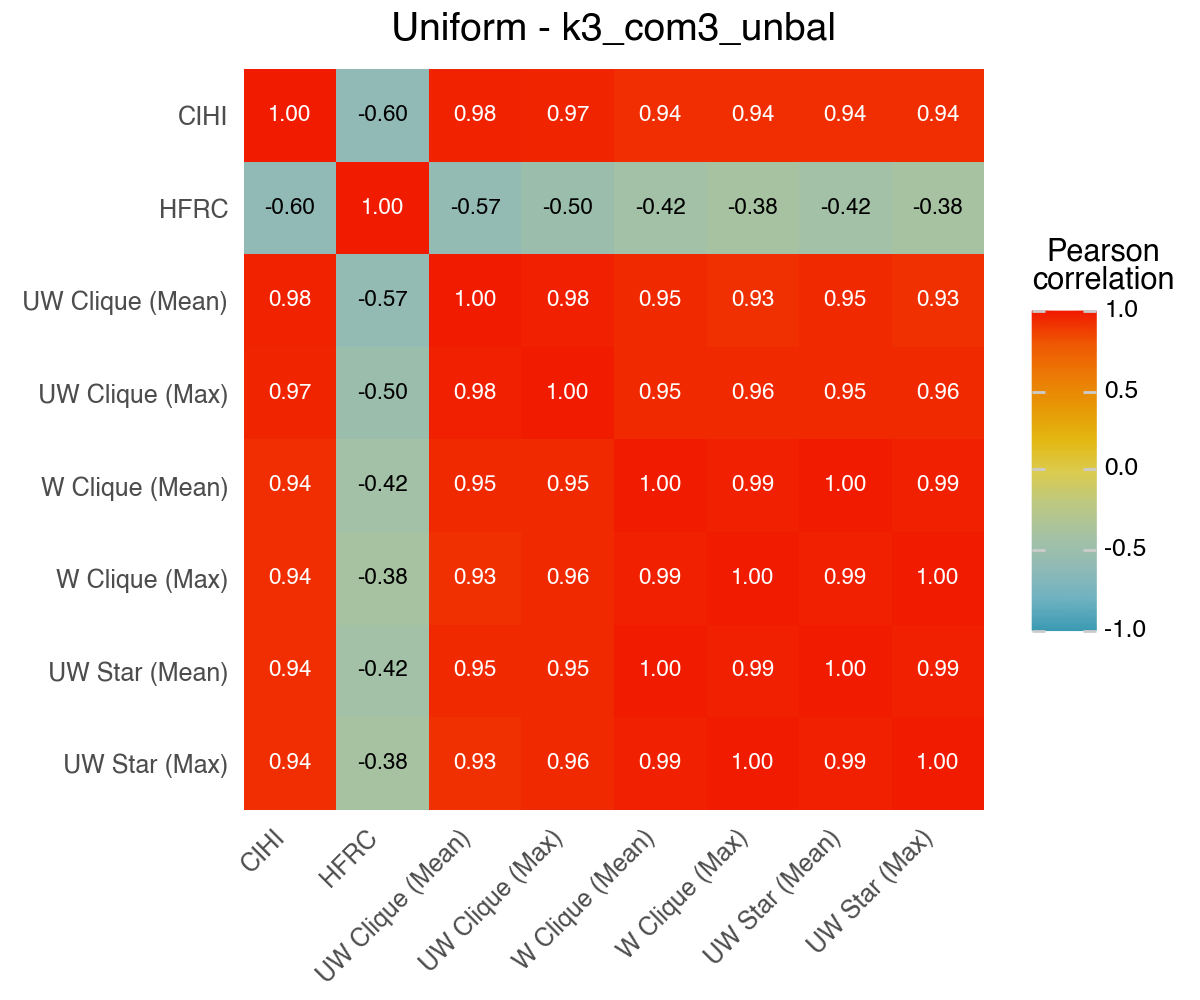

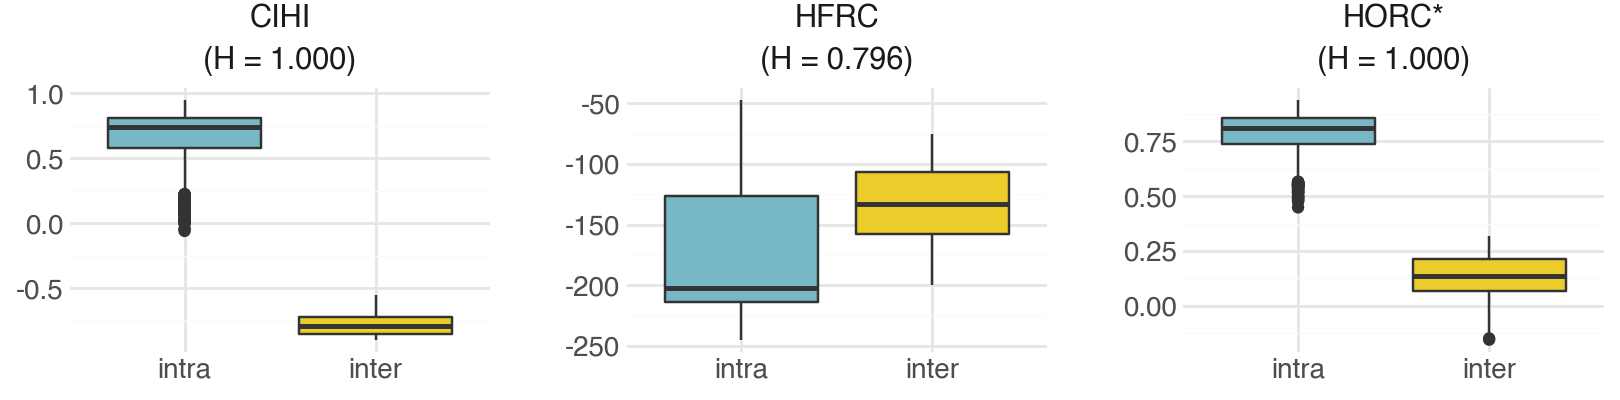

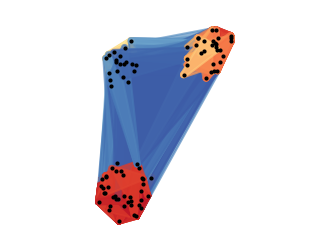

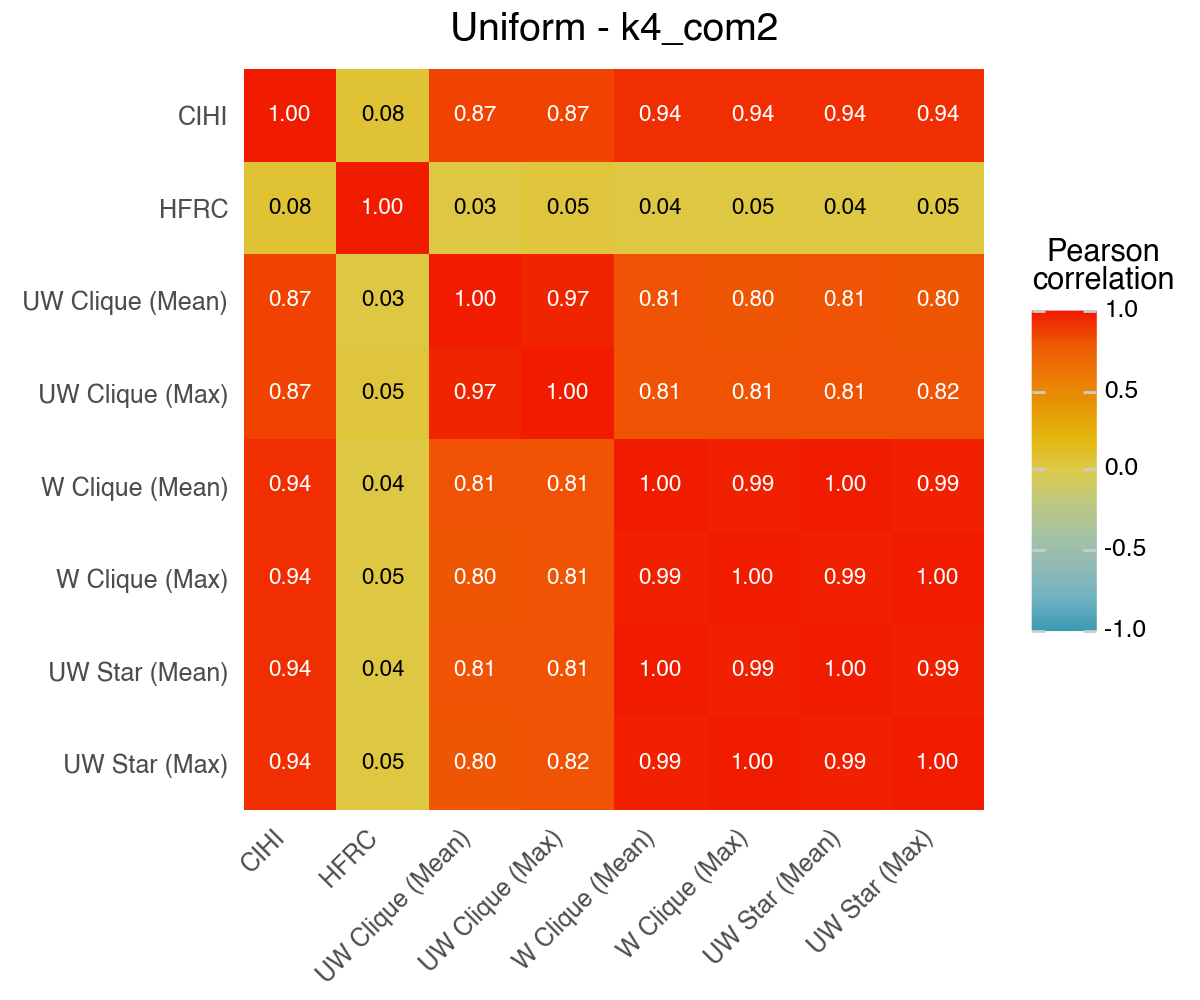

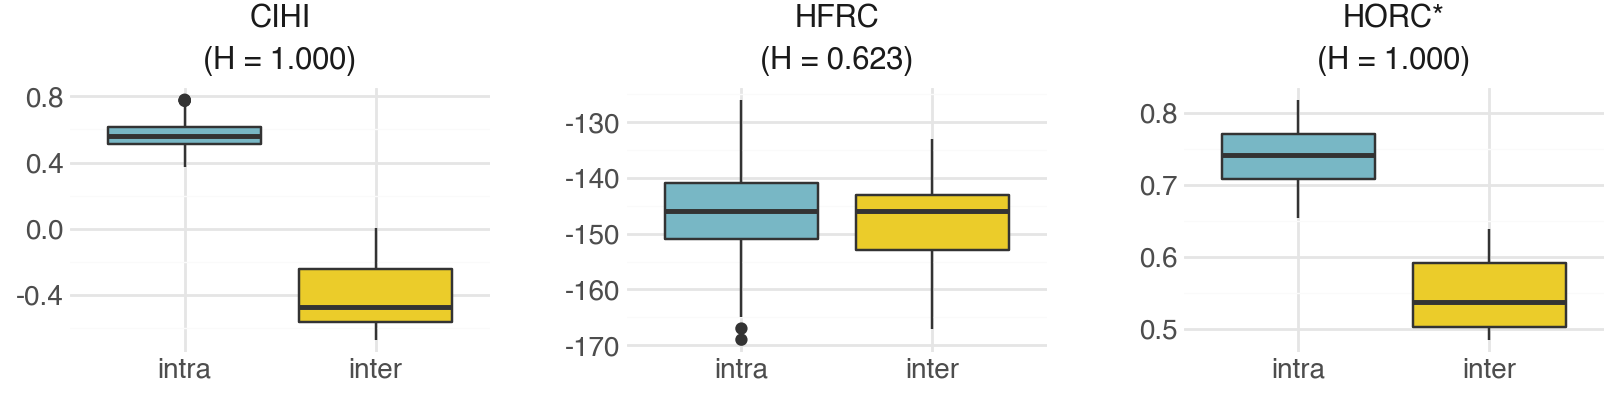

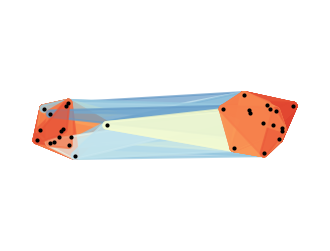

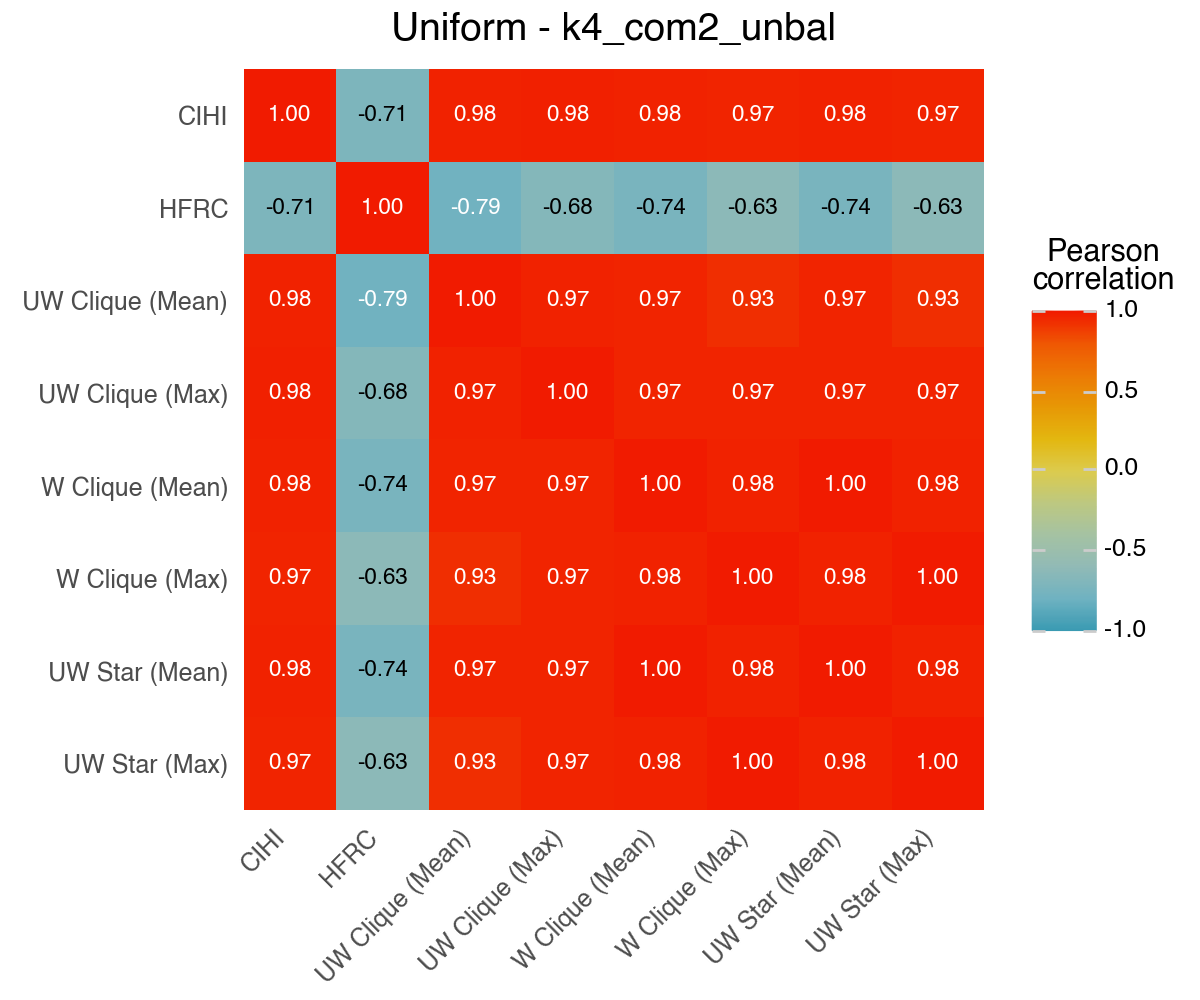

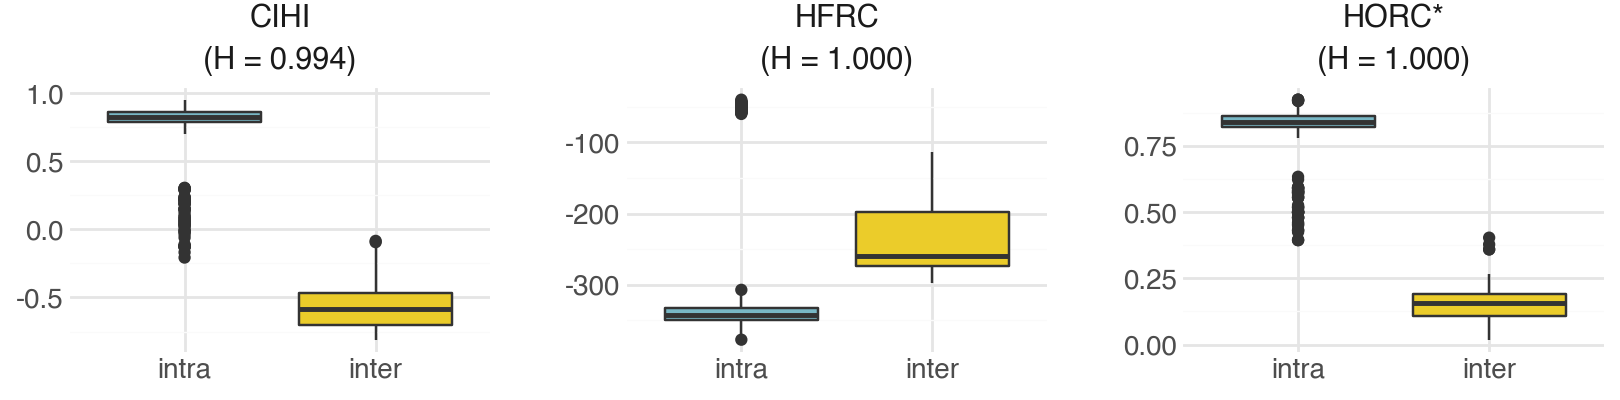

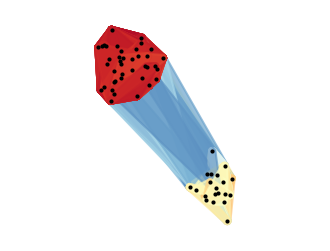

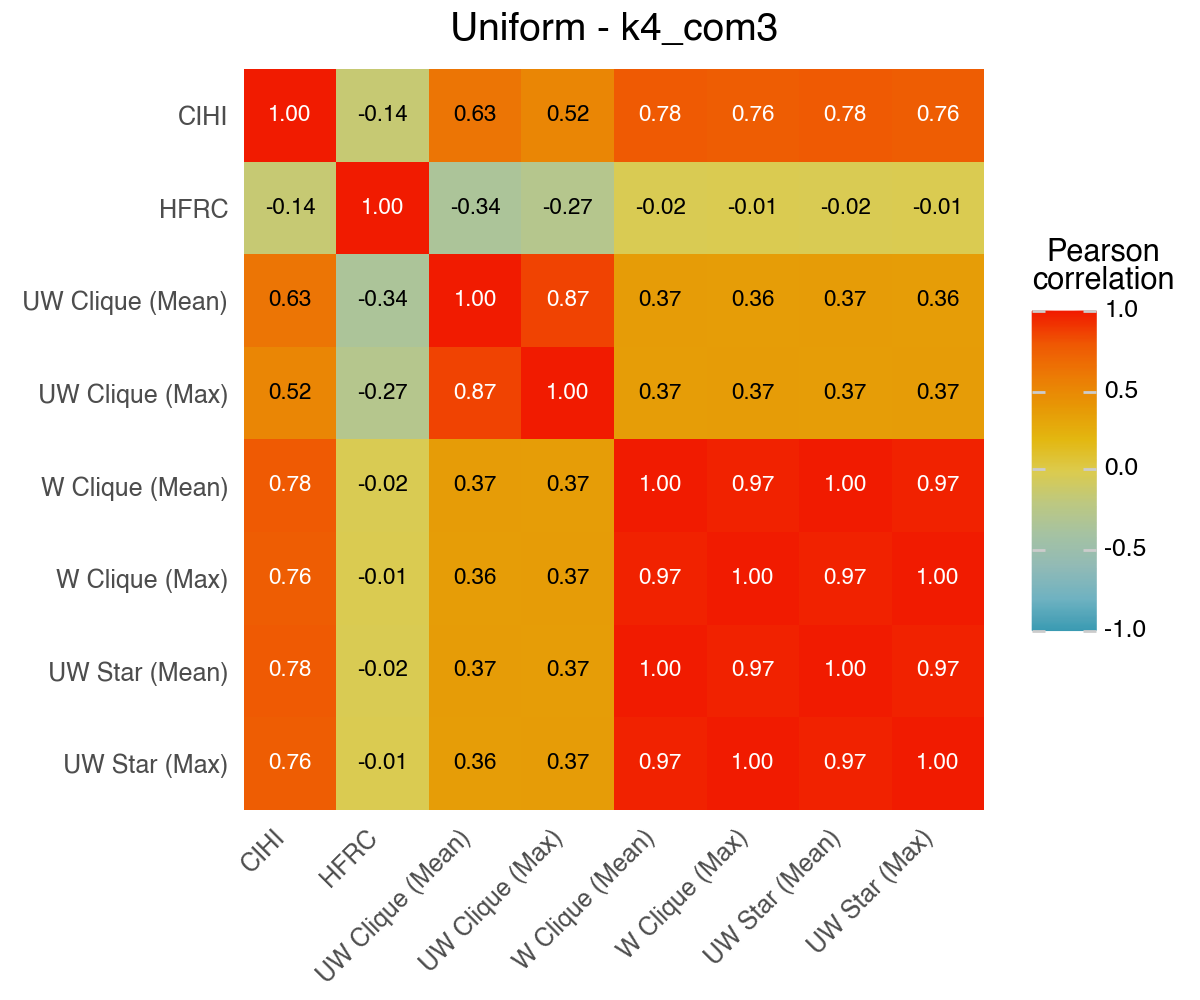

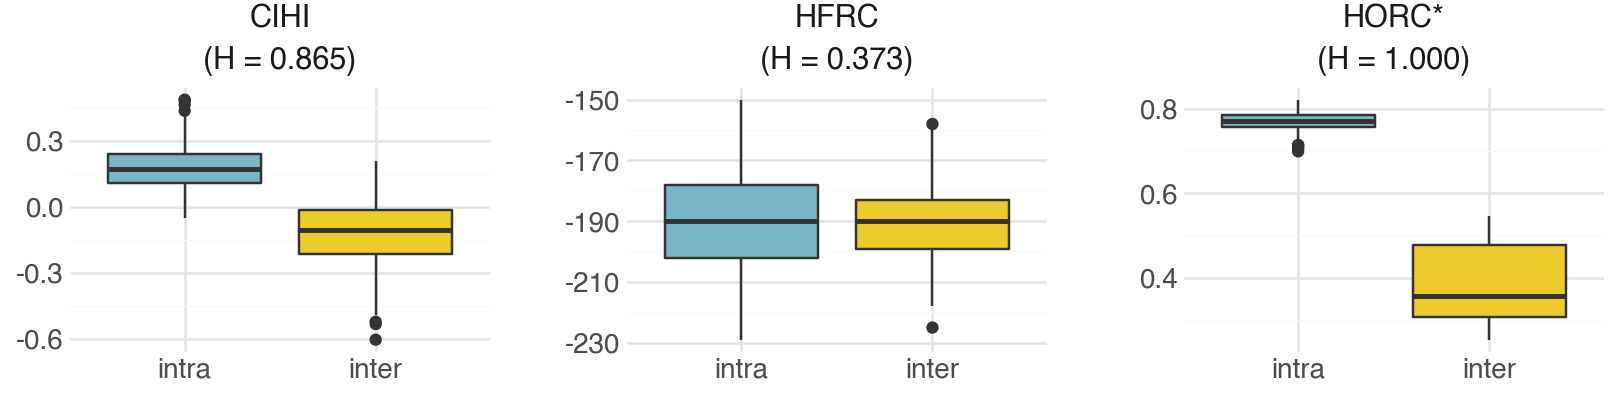

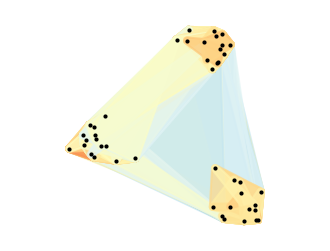

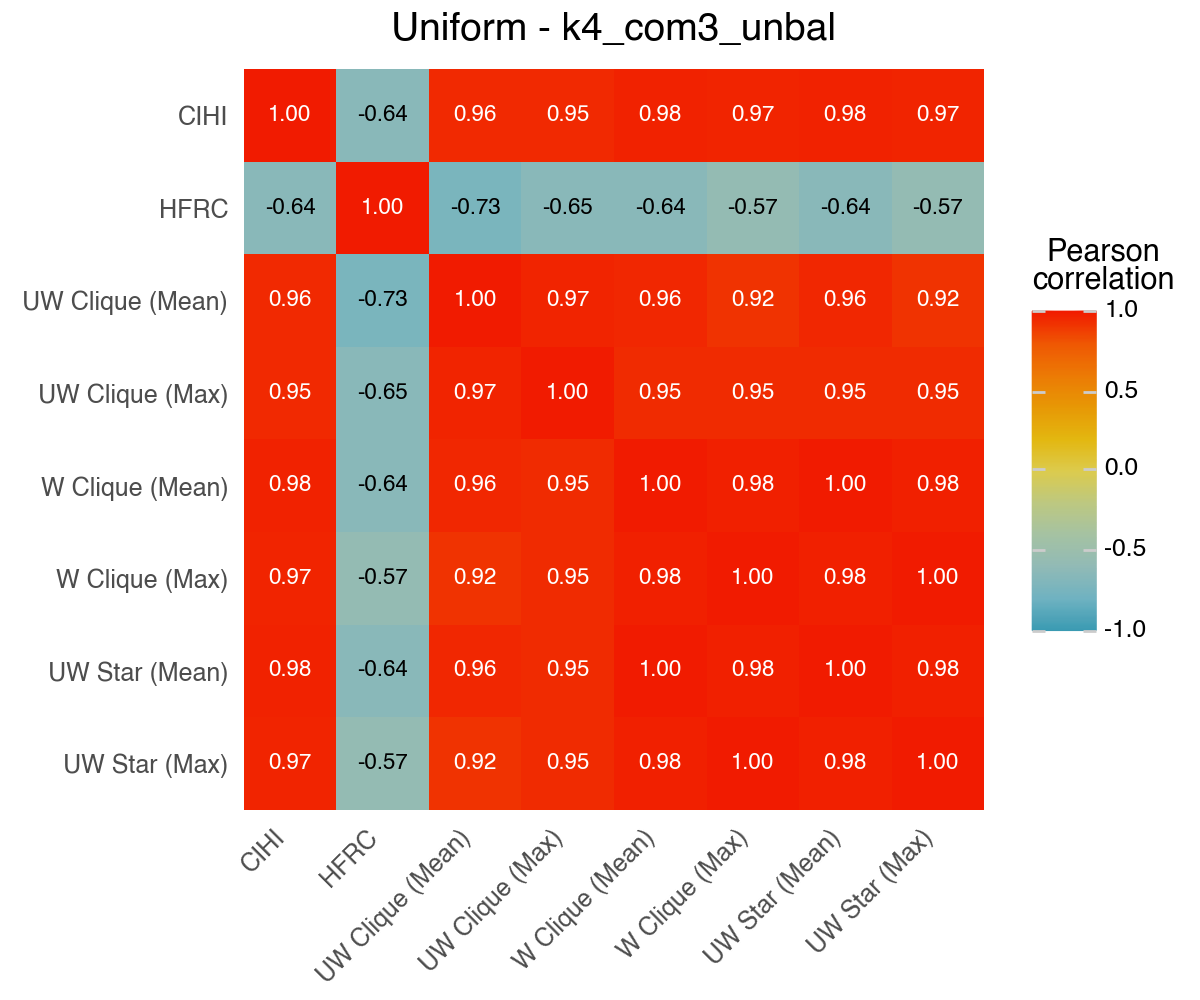

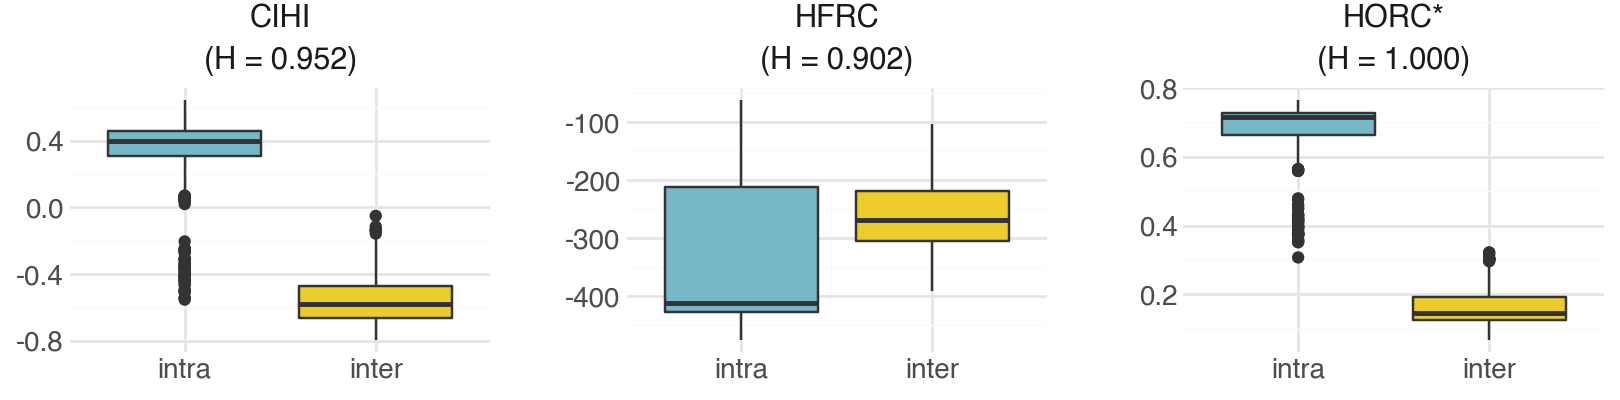

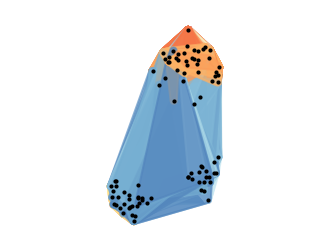

,config,best_horc,H_CIHI,H_HFRC,H_BE,H_HORC,cache_path,p_corr_path,p_path,vis_hg_path
0,k3_com2,horc,1.000000,0.753125,None,1.0,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...
1,k3_com2_unbal,horc,1.000000,0.951253,None,1.0,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...
2,k3_com3,horc_uw_clique_mean_a0p1,1.000000,0.670139,None,1.0,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...
3,k3_com3_unbal,horc,1.000000,0.796451,None,1.0,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...
4,k4_com2,horc_uw_clique_mean_a0p1,1.000000,0.622815,None,1.0,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...
5,k4_com2_unbal,horc_uw_clique_max_a0p0,0.993762,1.000000,None,1.0,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...
6,k4_com3,horc_w_clique_mean_a0p1,0.865278,0.373356,None,1.0,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...
7,k4_com3_unbal,horc_w_clique_max_a0p0,0.952299,0.902485,None,1.0,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...,/Users/shiyi/Library/Mobile Documents/com~appl...


In [10]:
"""Analyze the remaining uniform HSBM configurations."""
uniform_results = {}
configs_to_analyze = UNIFORM_CONFIGS

if "toy_result" in globals():
    uniform_results[UNIFORM_CONFIGS[0].name] = toy_result
    configs_to_analyze = UNIFORM_CONFIGS[1:]

for config in configs_to_analyze:
    result = analyze_uniform_config(
        config,
        show_hypergraph=False,
        include_be=INCLUDE_BE,
    )
    uniform_results[config.name] = result
    display(result["p_corr"])
    display(result["p"])
    result["vis_hg"] = vis_hg(result["ds"], save_path=result["figure_paths"]["vis_hg"])

uniform_summary = pd.DataFrame(
    {
        "config": name,
        "best_horc": result["best_horc"],
        "H_CIHI": result["h_values"]["cihi"],
        "H_HFRC": result["h_values"]["hfrc"],
        "H_BE": result["h_values"].get("be"),
        "H_HORC": result["h_values"]["horc"],
        "cache_path": result["cache_path"],
        "p_corr_path": result["figure_paths"]["p_corr"],
        "p_path": result["figure_paths"]["p"],
        "vis_hg_path": result["figure_paths"]["vis_hg"],
    }
    for name, result in uniform_results.items()
)

uniform_summary